In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# powerpoint - old data

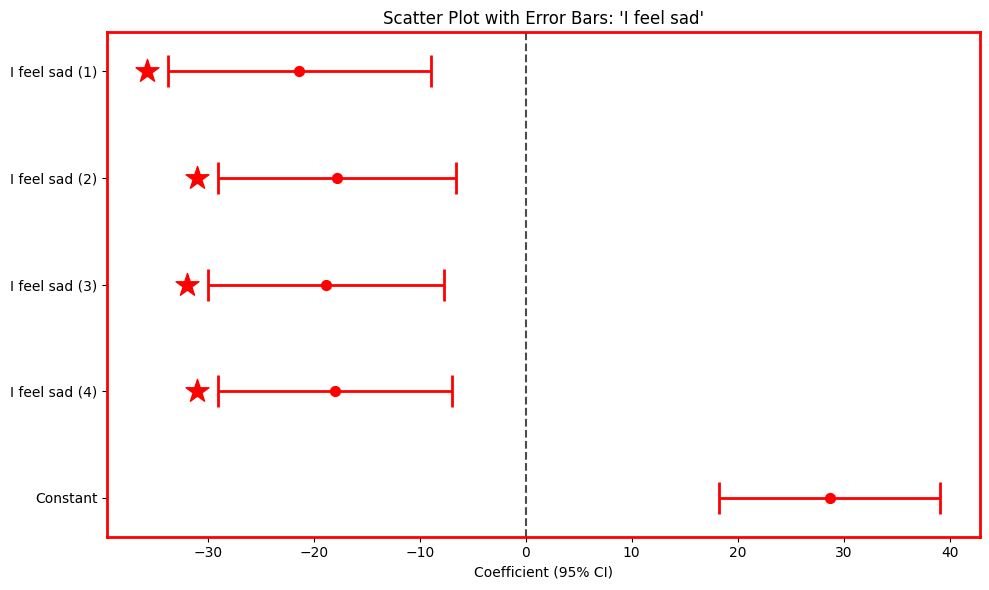

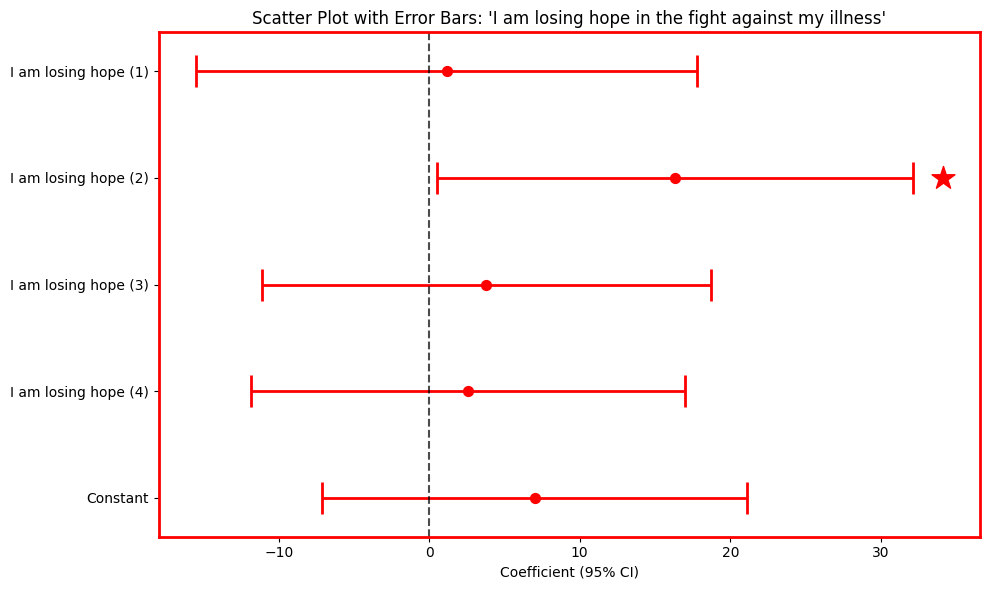

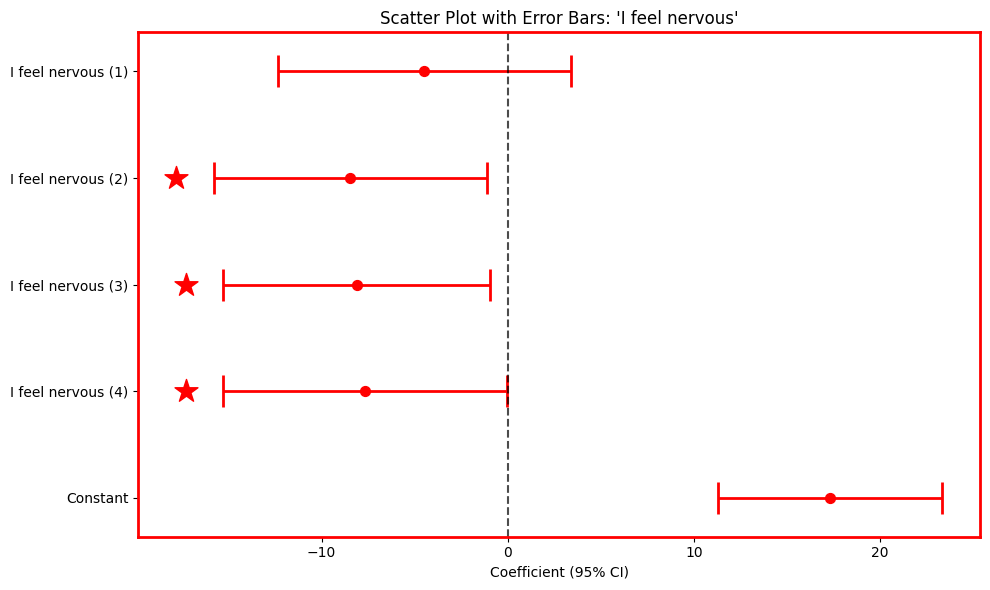

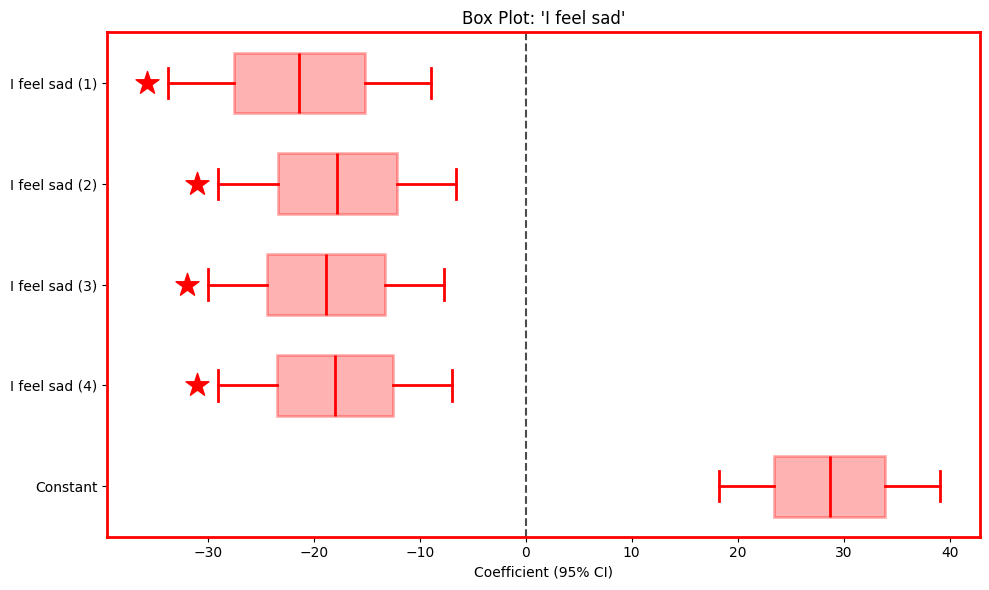

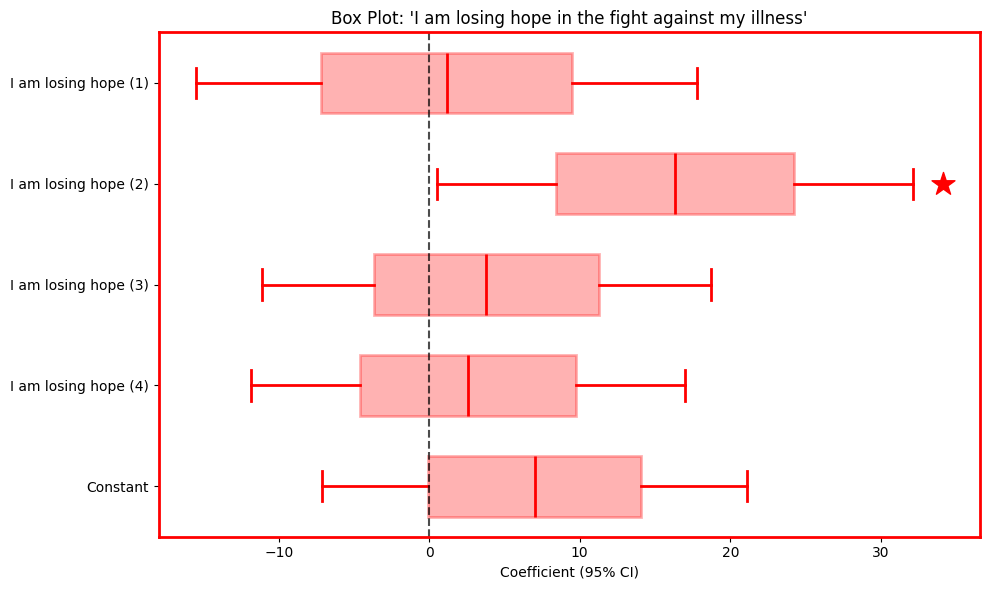

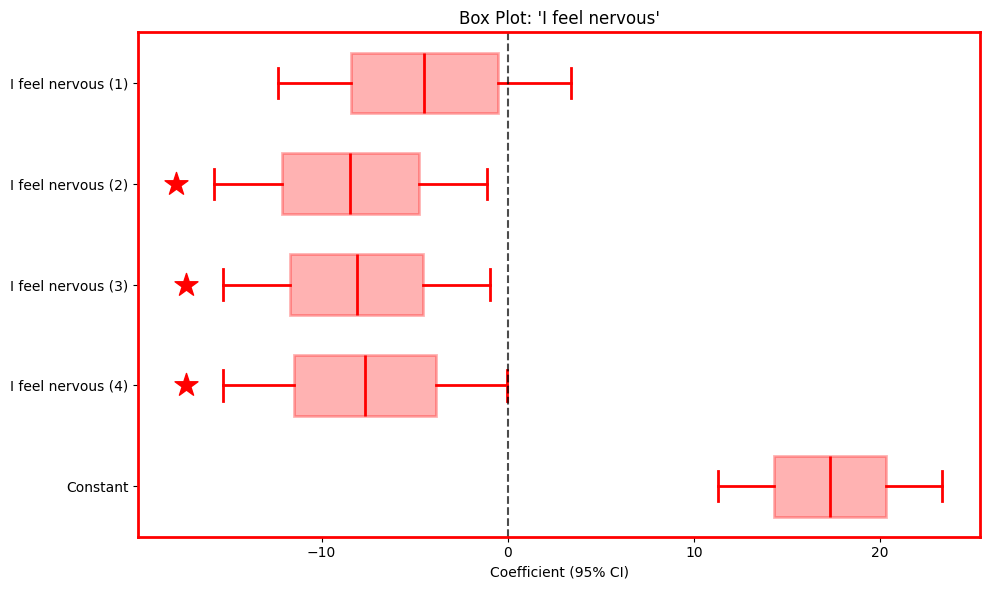

In [7]:

# Create dataframes from the regression tables
# Table 1: "I feel sad"
sad_data = pd.DataFrame({
    'Variable': ['I feel sad (1)', 'I feel sad (2)', 'I feel sad (3)', 'I feel sad (4)', 'Constant'],
    'Coefficient': [-21.35, -17.79, -18.84, -17.98, 28.67],
    'Std_err': [6.29, 5.70, 5.63, 5.59, 5.30],
    'Lower_CI': [-33.74, -29.02, -29.94, -29.00, 18.23],
    'Upper_CI': [-8.96, -6.56, -7.74, -6.97, 39.11],
    'P_value': [0.00, 0.00, 0.00, 0.00, 0.00]  # Based on your P>t values
})

# Table 2: "I am losing hope in the fight against my illness"
hope_data = pd.DataFrame({
    'Variable': ['I am losing hope (1)', 'I am losing hope (2)', 'I am losing hope (3)', 'I am losing hope (4)', 'Constant'],
    'Coefficient': [1.15, 16.30, 3.80, 2.57, 7.00],
    'Std_err': [8.45, 8.02, 7.56, 7.30, 7.18],
    'Lower_CI': [-15.49, 0.49, -11.09, -11.81, -7.14],
    'Upper_CI': [17.80, 32.11, 18.70, 16.96, 21.14],
    'P_value': [0.89, 0.04, 0.62, 0.73, 0.33]  # Based on your P>t values
})

# Table 3: "I feel nervous"
nervous_data = pd.DataFrame({
    'Variable': ['I feel nervous (1)', 'I feel nervous (2)', 'I feel nervous (3)', 'I feel nervous (4)', 'Constant'],
    'Coefficient': [-4.48, -8.45, -8.12, -7.67, 17.32],
    'Std_err': [3.99, 3.73, 3.64, 3.86, 3.05],
    'Lower_CI': [-12.34, -15.80, -15.30, -15.28, 11.32],
    'Upper_CI': [3.39, -1.09, -0.94, -0.06, 23.32],
    'P_value': [0.26, 0.03, 0.03, 0.05, 0.00]  # Based on your P>t values
})

# Function to create scatter plot with error bars and vertical tails
def create_coef_plot(data, title, highlight_rows=None, highlight_color='red'):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot all rows
    y_pos = np.arange(len(data))[::-1]  # Reverse order to match the images
    
    # Plot error bars with vertical tails
    for i, (coef, lower, upper) in enumerate(zip(data['Coefficient'], data['Lower_CI'], data['Upper_CI'])):
        # Main horizontal line
        ax.hlines(y_pos[i], lower, upper, color='red', linewidth=2)
        
        # Vertical tails at ends (whiskers) - shorter now
        whisker_length = 0.15  # Reduced length of the vertical whiskers
        ax.vlines(lower, y_pos[i] - whisker_length, y_pos[i] + whisker_length, color='red', linewidth=2)
        ax.vlines(upper, y_pos[i] - whisker_length, y_pos[i] + whisker_length, color='red', linewidth=2)
        
        # Point for coefficient
        ax.scatter(coef, y_pos[i], color='red', s=50, zorder=3)
    
    # Add vertical line at 0
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.7)
    
    # Add stars next to significant elements (excluding Constant)
    if highlight_rows is not None:
        for row in highlight_rows:
            # Skip Constant row (usually the last row)
            if data.iloc[row]['Variable'] == 'Constant':
                continue
                
            # Calculate the position for the star (outside the error bar)
            x_star = data.iloc[row]['Upper_CI'] + 2  # Place star to the right of the upper CI
            
            # If coefficient is positive, place star to the right, otherwise to the left
            if data.iloc[row]['Coefficient'] < 0:
                x_star = data.iloc[row]['Lower_CI'] - 2  # Place star to the left of the lower CI
            
            ax.scatter(x_star, y_pos[row], marker='*', s=300, color='red', zorder=3)
    
    # Set labels and title
    ax.set_yticks(y_pos)
    ax.set_yticklabels(data['Variable'])
    ax.set_xlabel('Coefficient (95% CI)')
    ax.set_title(f"Scatter Plot with Error Bars: '{title}'")
    
    # Add a box around the plot
    for spine in ax.spines.values():
        spine.set_edgecolor('red')
        spine.set_linewidth(2)
    
    plt.tight_layout()
    return fig, ax

# Function to create box plots with stars outside the plot
def create_box_plot(data, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Number of variables
    n_vars = len(data)
    
    # Create positions
    positions = np.arange(n_vars)[::-1]  # Reverse order to match the images
    
    # Create boxplots
    bp = ax.boxplot([
        [data.iloc[i]['Lower_CI'], data.iloc[i]['Coefficient'], data.iloc[i]['Upper_CI']] 
        for i in range(n_vars)
    ], 
    vert=False,  # Horizontal box plots
    positions=positions,
    patch_artist=True,  # Fill with color
    widths=0.6
    )
    
    # Color boxes red
    for box in bp['boxes']:
        box.set(color='red', linewidth=2)
        box.set(facecolor='red', alpha=0.3)
    
    # Color the whiskers and caps red
    for whisker in bp['whiskers']:
        whisker.set(color='red', linewidth=2)
    for cap in bp['caps']:
        cap.set(color='red', linewidth=2)
    
    # Color the medians red and make them thicker
    for median in bp['medians']:
        median.set(color='red', linewidth=2)
    
    # Add star markers for significant elements (p <= 0.05) outside the plot, excluding Constant
    for i, (p_value, var_name) in enumerate(zip(data['P_value'], data['Variable'])):
        if p_value <= 0.05 and var_name != 'Constant':  # Now including p = 0.05 and excluding Constant
            # Calculate position for star
            x_star = data.iloc[i]['Upper_CI'] + 2  # Place star to the right of the upper CI
            
            # If coefficient is negative, place star to the left
            if data.iloc[i]['Coefficient'] < 0:
                x_star = data.iloc[i]['Lower_CI'] - 2  # Place star to the left of the lower CI
            
            # Add a red star outside the box
            ax.scatter(x_star, positions[i], marker='*', s=300, color='red', zorder=3)
    
    # Set labels and title
    ax.set_yticks(positions)
    ax.set_yticklabels(data['Variable'])
    ax.set_xlabel('Coefficient (95% CI)')
    ax.set_title(f"Box Plot: '{title}'")
    
    # Add vertical line at 0
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.7)
    
    # Add a box around the plot
    for spine in ax.spines.values():
        spine.set_edgecolor('red')
        spine.set_linewidth(2)
    
    plt.tight_layout()
    return fig, ax

# Create the error bar plots
# For "I feel sad", all non-Constant rows are significant
fig1, ax1 = create_coef_plot(sad_data, "I feel sad", highlight_rows=[0, 1, 2, 3])

# For "I am losing hope", only row 2 is significant
fig2, ax2 = create_coef_plot(hope_data, "I am losing hope in the fight against my illness", highlight_rows=[1])

# For "I feel nervous", rows 2, 3, and 4 are significant (including row 4 with p=0.05)
fig3, ax3 = create_coef_plot(nervous_data, "I feel nervous", highlight_rows=[1, 2, 3])

# Create the box plots
fig4, ax4 = create_box_plot(sad_data, "I feel sad")
fig5, ax5 = create_box_plot(hope_data, "I am losing hope in the fight against my illness")
fig6, ax6 = create_box_plot(nervous_data, "I feel nervous")

# Show the plots
plt.show()

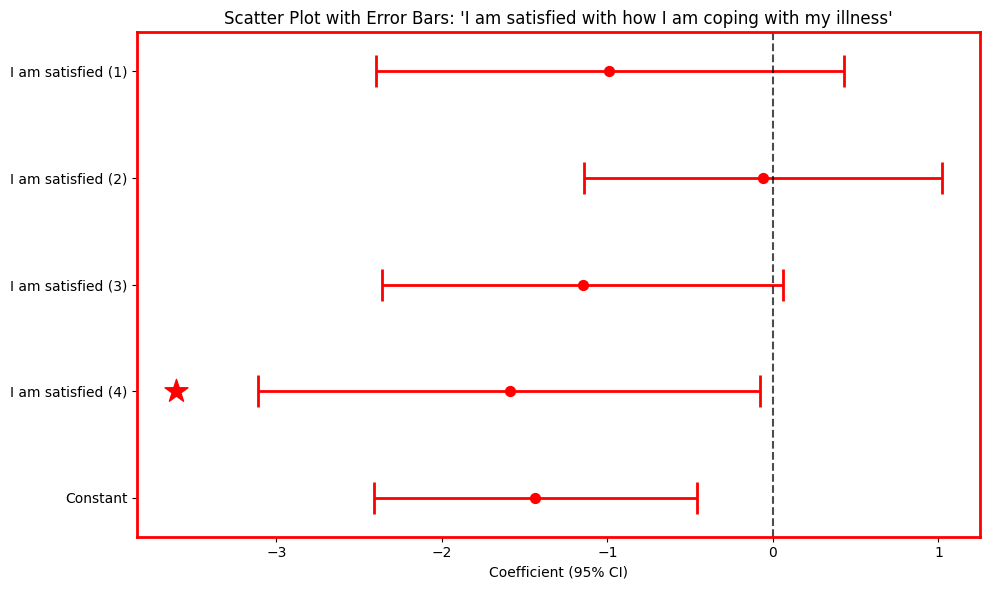

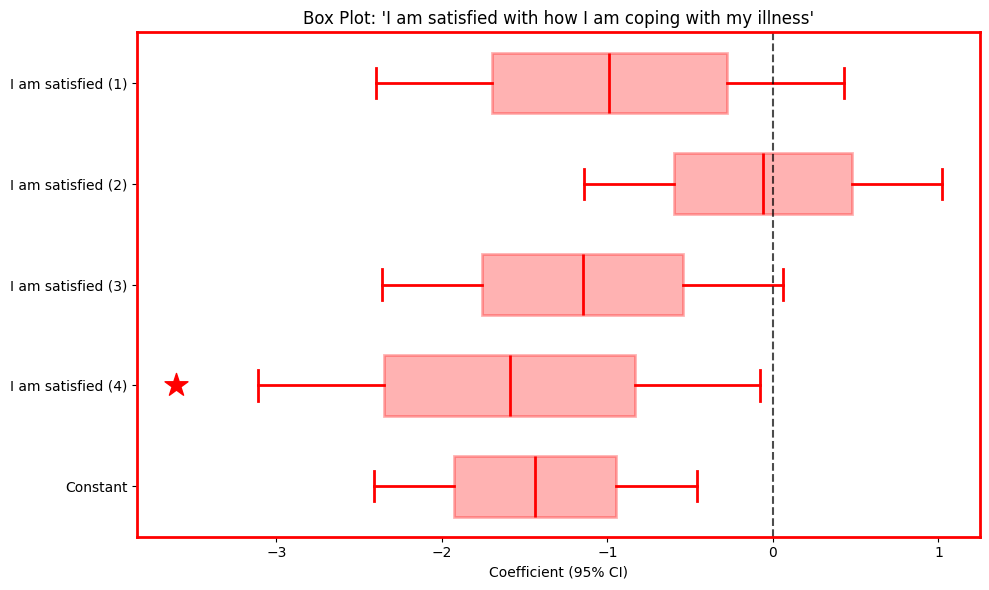

In [8]:

# Create dataframe from the new table
satisfied_data = pd.DataFrame({
    'Variable': ['I am satisfied (1)', 'I am satisfied (2)', 'I am satisfied (3)', 'I am satisfied (4)', 'Constant'],
    'Coefficient': [-0.99, -0.06, -1.15, -1.59, -1.44],
    'Std_err': [0.72, 0.55, 0.62, 0.77, 0.50],
    'Lower_CI': [-2.40, -1.14, -2.36, -3.11, -2.41],
    'Upper_CI': [0.43, 1.02, 0.06, -0.08, -0.46],
    'P_value': [0.17, 0.92, 0.06, 0.04, 0.00]  # Based on your P>t values
})

# Function to create scatter plot with error bars and vertical tails
def create_coef_plot(data, title, highlight_rows=None, highlight_color='red'):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot all rows
    y_pos = np.arange(len(data))[::-1]  # Reverse order to match the images
    
    # Plot error bars with vertical tails
    for i, (coef, lower, upper) in enumerate(zip(data['Coefficient'], data['Lower_CI'], data['Upper_CI'])):
        # Main horizontal line
        ax.hlines(y_pos[i], lower, upper, color='red', linewidth=2)
        
        # Vertical tails at ends (whiskers) - shorter now
        whisker_length = 0.15  # Reduced length of the vertical whiskers
        ax.vlines(lower, y_pos[i] - whisker_length, y_pos[i] + whisker_length, color='red', linewidth=2)
        ax.vlines(upper, y_pos[i] - whisker_length, y_pos[i] + whisker_length, color='red', linewidth=2)
        
        # Point for coefficient
        ax.scatter(coef, y_pos[i], color='red', s=50, zorder=3)
    
    # Add vertical line at 0
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.7)
    
    # Add stars next to significant elements (excluding Constant)
    if highlight_rows is not None:
        for row in highlight_rows:
            # Skip Constant row (usually the last row)
            if data.iloc[row]['Variable'] == 'Constant':
                continue
                
            # Calculate the position for the star (outside the error bar)
            x_star = data.iloc[row]['Upper_CI'] + 0.5  # Place star to the right of the upper CI
            
            # If coefficient is positive, place star to the right, otherwise to the left
            if data.iloc[row]['Coefficient'] < 0:
                x_star = data.iloc[row]['Lower_CI'] - 0.5  # Place star to the left of the lower CI
            
            ax.scatter(x_star, y_pos[row], marker='*', s=300, color='red', zorder=3)
    
    # Set labels and title
    ax.set_yticks(y_pos)
    ax.set_yticklabels(data['Variable'])
    ax.set_xlabel('Coefficient (95% CI)')
    ax.set_title(f"Scatter Plot with Error Bars: '{title}'")
    
    # Add a box around the plot
    for spine in ax.spines.values():
        spine.set_edgecolor('red')
        spine.set_linewidth(2)
    
    plt.tight_layout()
    return fig, ax

# Function to create box plots with stars outside the plot
def create_box_plot(data, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Number of variables
    n_vars = len(data)
    
    # Create positions
    positions = np.arange(n_vars)[::-1]  # Reverse order to match the images
    
    # Create boxplots
    bp = ax.boxplot([
        [data.iloc[i]['Lower_CI'], data.iloc[i]['Coefficient'], data.iloc[i]['Upper_CI']] 
        for i in range(n_vars)
    ], 
    vert=False,  # Horizontal box plots
    positions=positions,
    patch_artist=True,  # Fill with color
    widths=0.6
    )
    
    # Color boxes red
    for box in bp['boxes']:
        box.set(color='red', linewidth=2)
        box.set(facecolor='red', alpha=0.3)
    
    # Color the whiskers and caps red
    for whisker in bp['whiskers']:
        whisker.set(color='red', linewidth=2)
    for cap in bp['caps']:
        cap.set(color='red', linewidth=2)
    
    # Color the medians red and make them thicker
    for median in bp['medians']:
        median.set(color='red', linewidth=2)
    
    # Add star markers for significant elements (p <= 0.05) outside the plot, excluding Constant
    for i, (p_value, var_name) in enumerate(zip(data['P_value'], data['Variable'])):
        if p_value <= 0.05 and var_name != 'Constant':  # Now including p = 0.05 and excluding Constant
            # Calculate position for star
            x_star = data.iloc[i]['Upper_CI'] + 0.5  # Place star to the right of the upper CI
            
            # If coefficient is negative, place star to the left
            if data.iloc[i]['Coefficient'] < 0:
                x_star = data.iloc[i]['Lower_CI'] - 0.5  # Place star to the left of the lower CI
            
            # Add a red star outside the box
            ax.scatter(x_star, positions[i], marker='*', s=300, color='red', zorder=3)
    
    # Set labels and title
    ax.set_yticks(positions)
    ax.set_yticklabels(data['Variable'])
    ax.set_xlabel('Coefficient (95% CI)')
    ax.set_title(f"Box Plot: '{title}'")
    
    # Add vertical line at 0
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.7)
    
    # Add a box around the plot
    for spine in ax.spines.values():
        spine.set_edgecolor('red')
        spine.set_linewidth(2)
    
    plt.tight_layout()
    return fig, ax

# For "I am satisfied", row 4 is significant (p = 0.04) and row 3 might be included if p = 0.06 is considered borderline significant
# We'll only mark row 4 as significant per your instructions (p <= 0.05)
fig1, ax1 = create_coef_plot(satisfied_data, "I am satisfied with how I am coping with my illness", highlight_rows=[3])

# Create the box plot
fig2, ax2 = create_box_plot(satisfied_data, "I am satisfied with how I am coping with my illness")

# Show the plots
plt.show()